In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1989, 13)
Test shape: (498, 12)


,id,Date,Open,High,Low,Close,Volume,feature_ret_1d,feature_ret_5d,feature_sma_20_ratio,feature_vol_ratio_20d,feature_high_low_spread,target
0,0,2014-01-30,145.258090,146.054110,144.795091,145.582993,118938100,0.010601,-0.019476,-0.016530,1.018317,0.008648,0.021090
1,1,2014-01-31,143.779734,145.631706,143.706633,144.730087,194677900,-0.005859,-0.003969,-0.021019,1.614905,0.013301,0.032776
2,2,2014-02-03,144.559525,144.884428,141.196732,141.472900,254837100,-0.022505,-0.021572,-0.040753,1.972072,0.026066,0.057817
3,3,2014-02-04,142.106482,142.829401,141.424179,142.463882,165012400,0.007005,-0.020551,-0.032176,1.249410,0.009864,0.043503
4,4,2014-02-05,141.968372,142.601941,141.099250,142.285156,164230500,-0.001255,-0.012292,-0.031169,1.207785,0.010561,0.050979


# Exploratory Data Analysis

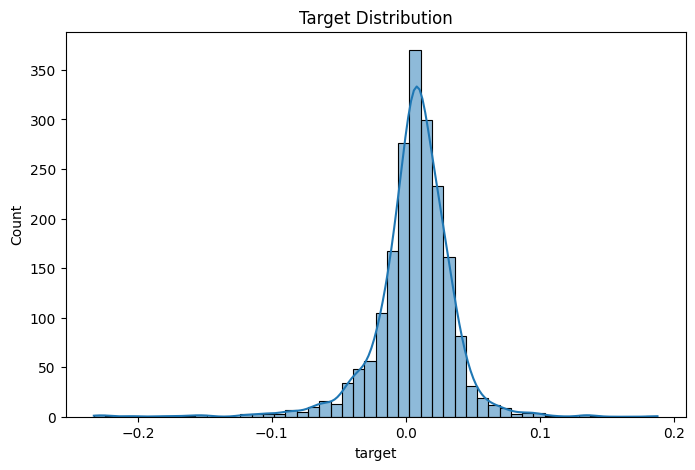

count    1989.000000
mean        0.006150
std         0.029940
min        -0.232884
25%        -0.004963
50%         0.008224
75%         0.021779
max         0.187979
Name: target, dtype: float64


,0
id,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
feature_ret_1d,0
feature_ret_5d,0
feature_sma_20_ratio,0


In [ ]:
# Observing Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(train["target"], bins=50, kde=True)
plt.title("Target Distribution")
plt.show()

# Generating statistics related to Target
print(train["target"].describe())

# Checking for missing values
train.isnull().sum()

No need to use imputer in our pipeline as there are 0 missing values in any column.

target                     1.000000
feature_high_low_spread    0.102121
feature_vol_ratio_20d     -0.073738
id                         0.063760
feature_sma_20_ratio      -0.060643
Volume                     0.049455
feature_ret_1d            -0.039154
High                       0.020714
Open                       0.019840
Close                      0.018658
Low                        0.018621
feature_ret_5d            -0.013679
Name: target, dtype: float64


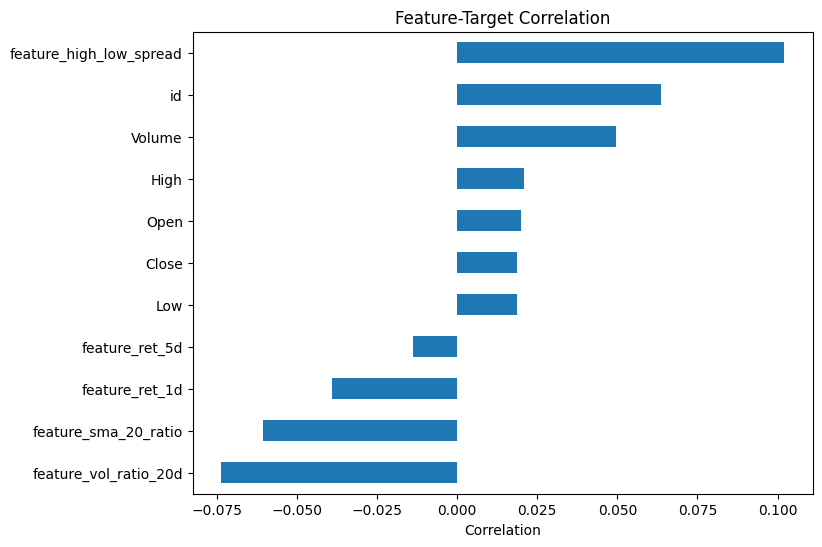

In [ ]:
# Feature-Target Correlation Analysis
numeric_cols = train.select_dtypes(include=np.number).columns
feature_target_corr = (train[numeric_cols].corr()["target"].sort_values(key=np.abs, ascending=False))
print(feature_target_corr)

plt.figure(figsize=(8,6))
feature_target_corr.drop("target").sort_values().plot(kind="barh")
plt.title("Feature-Target Correlation")
plt.xlabel("Correlation")
plt.show()

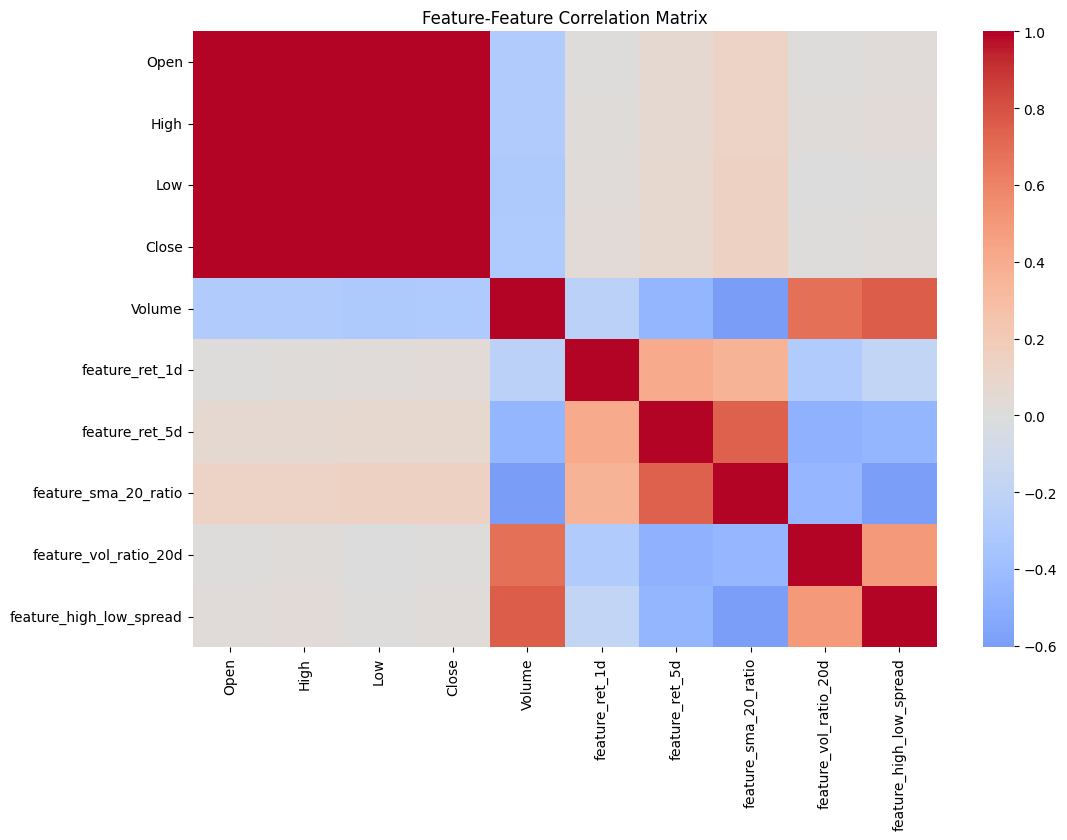

In [ ]:
# Feature-Feature Correlation Analysis
feature_cols = [c for c in train.columns if c not in ["id", "Date", "target"]]
corr_matrix = train[feature_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,cmap="coolwarm",center=0)
plt.title("Feature-Feature Correlation Matrix")
plt.show()

In [ ]:
# Finding feature pairs with correlation > 0.85
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, column]) and upper.loc[row, column] > 0.85
]

for pair in high_corr:
    print(pair)

('High', 'Open', np.float64(0.9998306963124841))
('Low', 'Open', np.float64(0.9997813991783552))
('Low', 'High', np.float64(0.9996052048507167))
('Close', 'Open', np.float64(0.9996846312011309))
('Close', 'High', np.float64(0.9997639169617463))
('Close', 'Low', np.float64(0.9998015732981754))


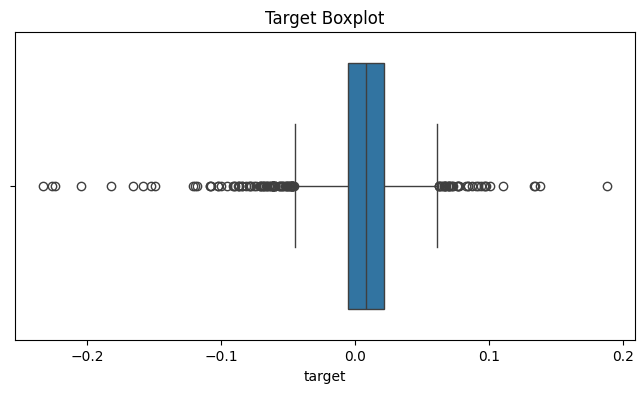

Number of outliers: 36
Percentage: 1.8099547511312217


In [ ]:
# Outlier Analysis
plt.figure(figsize=(8,4))
sns.boxplot(x=train["target"])
plt.title("Target Boxplot")
plt.show()

mean = train["target"].mean()
std = train["target"].std()
lower = mean - 3*std
upper = mean + 3*std
outliers = train[(train["target"] < lower) |(train["target"] > upper)]

print("Number of outliers:", len(outliers))
print("Percentage:", 100*len(outliers)/len(train))

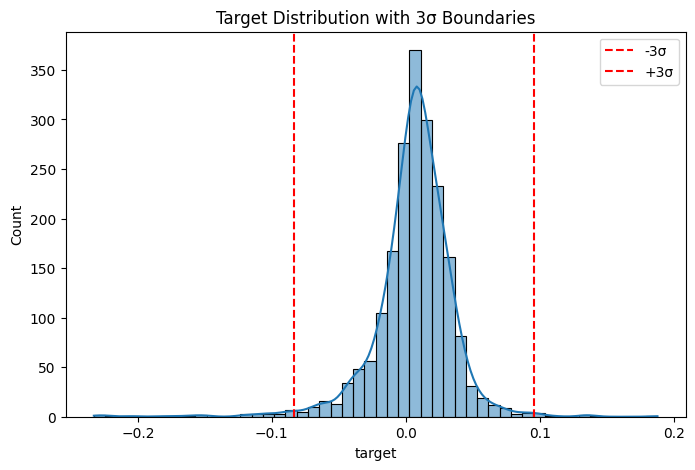

In [ ]:
# Analyzing Outliers using Clipping boundaries
plt.figure(figsize=(8,5))
sns.histplot(train["target"], bins=50, kde=True)
plt.axvline(lower, color="red", linestyle="--", label="-3σ")
plt.axvline(upper, color="red", linestyle="--", label="+3σ")
plt.legend()
plt.title("Target Distribution with 3σ Boundaries")
plt.show()

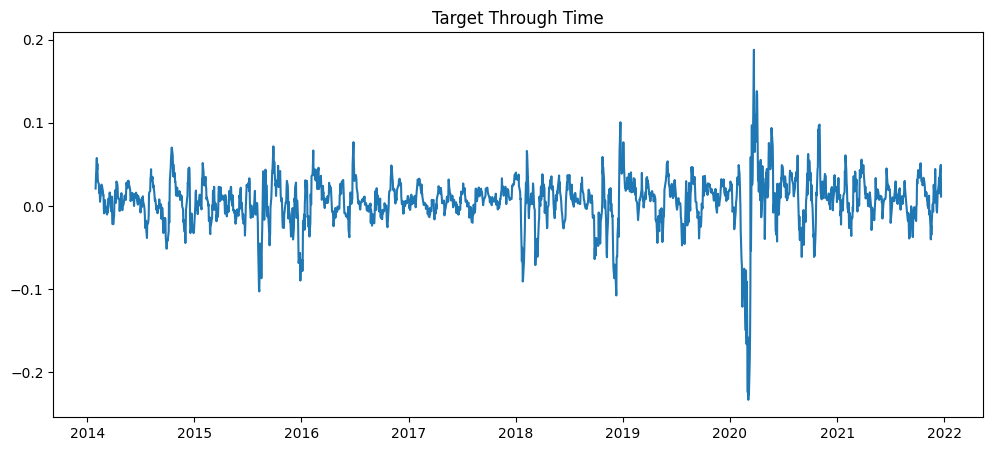

In [ ]:
# Checking for volatility regimes
train["Date"] = pd.to_datetime(train["Date"])
plt.figure(figsize=(12,5))
plt.plot(train["Date"], train["target"])
plt.title("Target Through Time")
plt.show()

**Observations:**

1. Target distribution is roughly bell-shaped and mean is close to zero.
2. Clearly, open, high, low, close are basically carrying the same information as their feature-feature correlation is very high.
3. Mean and median show a slight positive drift as stock market generally trends upwards.
4. Heavy tail is confirmed by the fact that min is -0.2329, max is 0.1880 and std= 0.0299. 23% move is nearly 8 standard deviations away.
5. The dataset has multiple market regimes. 2014-19 is mostly stable as returns oscillate about zero. 2020 shows a huge volatility spike as elucidated by giant dip of -0.23 and a rebound of +0.18.

# FEATURE ENGINEERING

In [ ]:
for df in [train, test]:

    # Date Features: to capture the regime effects
    df["Date"] = pd.to_datetime(df["Date"])

    df["quarter"] = df["Date"].dt.quarter
    df["dayofweek"] = df["Date"].dt.dayofweek

    # RELATIVE PRICE FEATURES

    # Intraday return: measures daily direction, percentage change between the opening price and the closing price
    df["intraday_return"] = ((df["Close"] - df["Open"])/ df["Open"] )

    # Body size: measures conviction of move
    df["body_size"] = (np.abs(df["Close"] - df["Open"])/ df["Open"])

    # Upper wick: gap between the highest price reached that day and the top of the candlestick body
    df["upper_shadow"] = (df["High"]- np.maximum(df["Open"], df["Close"])) / df["Close"]

    # Lower wick: gap between the bottom of the candlestick body and the lowest price reached
    df["lower_shadow"] = (np.minimum(df["Open"], df["Close"])- df["Low"]) / df["Close"]

    # VOLUME FEATURES
    df["log_volume"] = np.log1p(df["Volume"])

    # INTERACTION FEATURES

    # Momentum × Trend: Trend alignment. It amplifies the signal when short-term price action agrees with the broader trend.
    df["ret5d_sma"] = (df["feature_ret_5d"]* df["feature_sma_20_ratio"])

    # Momentum interaction: checks if the immediate action (what happened today) supports the recent action (this week)
    df["ret_interaction"] = (df["feature_ret_1d"]* df["feature_ret_5d"])

    # LAG FEATURES (Add this right before # DROP RAW COLUMNS)
    df["lag_ret_1d"] = df["feature_ret_1d"].shift(1).fillna(0)
    df["lag_ret_5d"] = df["feature_ret_5d"].shift(1).fillna(0)

    # ROLLING VOLATILITY
    df["roll_vol_5d"] = df["feature_ret_1d"].rolling(window=5).std().fillna(method='bfill')

# DROP RAW COLUMNS
drop_cols = ["id","Date","Open","High","Low","Close", "Volume"]

# Note, the features which were already present are:
# (a) feature_sma_20_ratio: rolling statistic feature which measures distance from average
# (b) feature_ret_1d: measures very short term momentum
# (c) feature_ret_5d: measures weakly momentum
# (d) feature_vol_ratio_20d: compares short-term volatility with 20-day volatility
# (e) feature_high_low_spread: measures daily volatility

train_model = train.drop(columns=drop_cols)
test_model = test.drop(columns=drop_cols)

/tmp/ipykernel_406/2750048871.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["roll_vol_5d"] = df["feature_ret_1d"].rolling(window=5).std().fillna(method='bfill')
/tmp/ipykernel_406/2750048871.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["roll_vol_5d"] = df["feature_ret_1d"].rolling(window=5).std().fillna(method='bfill')


target                     1.000000
roll_vol_5d                0.107507
feature_high_low_spread    0.102121
upper_shadow               0.098893
feature_vol_ratio_20d     -0.073738
body_size                  0.072608
feature_sma_20_ratio      -0.060643
log_volume                 0.049883
intraday_return           -0.047619
ret_interaction            0.043147
feature_ret_1d            -0.039154
ret5d_sma                  0.035242
lower_shadow               0.027849
lag_ret_1d                 0.022186
feature_ret_5d            -0.013679
lag_ret_5d                -0.013406
quarter                    0.010570
dayofweek                  0.000155
Name: target, dtype: float64


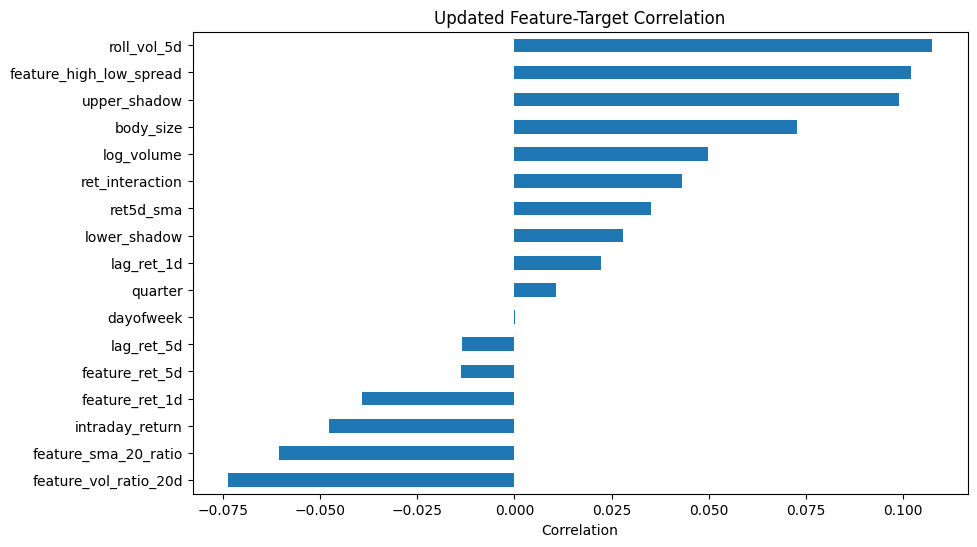

In [ ]:
feature_target_corr = (train_model.corr(numeric_only=True)["target"].sort_values(key=np.abs, ascending=False))
print(feature_target_corr)


plt.figure(figsize=(10,6))
feature_target_corr.drop("target").sort_values().plot(kind="barh")
plt.title("Updated Feature-Target Correlation")
plt.xlabel("Correlation")
plt.show()

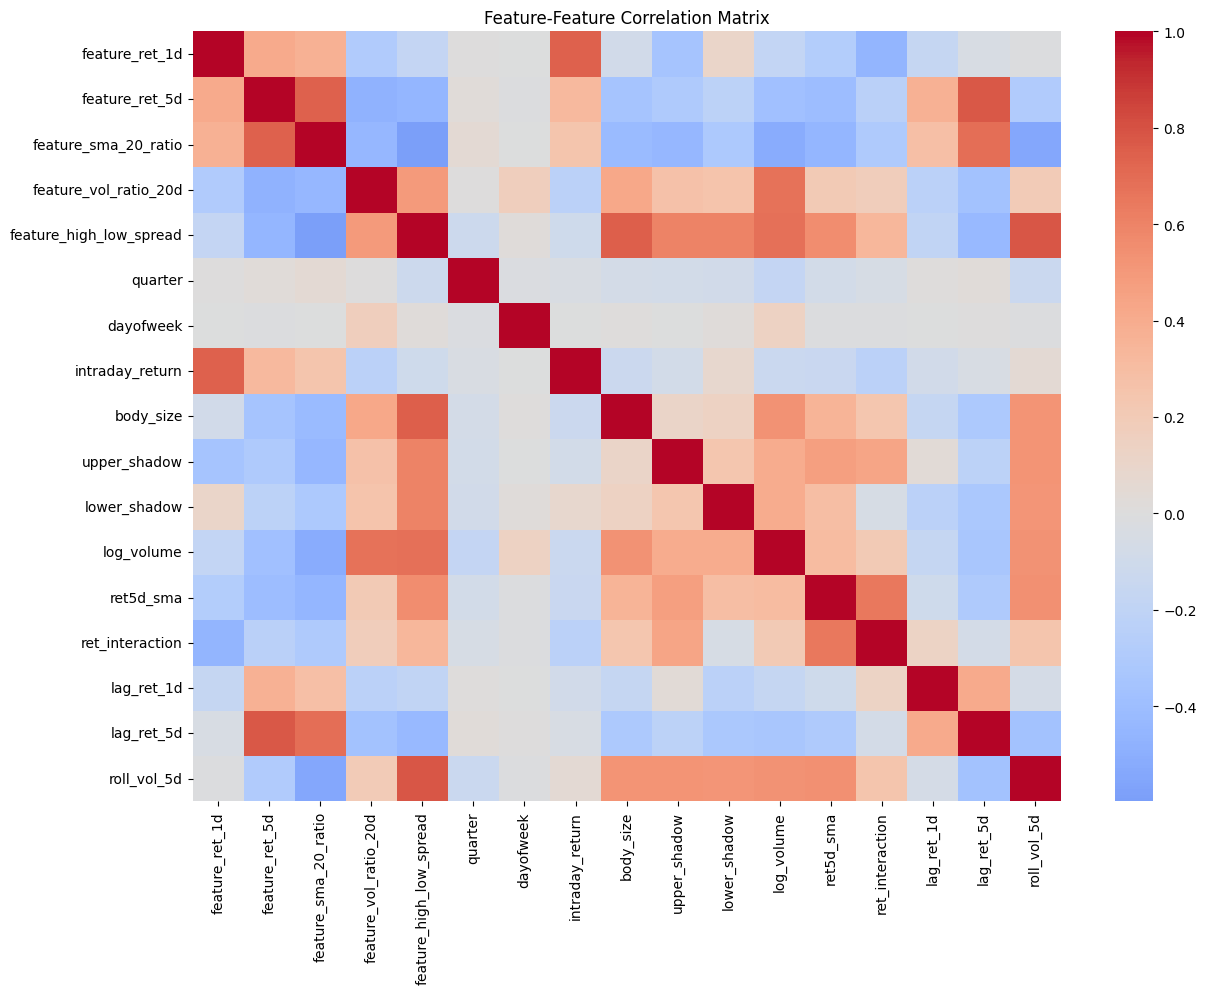

In [ ]:
feature_cols = [
    col for col in train_model.columns
    if col != "target"
]
corr_matrix = train_model[feature_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix,cmap="coolwarm",center=0)
plt.title("Feature-Feature Correlation Matrix")
plt.show()

In [ ]:
corr_matrix = train_model[feature_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85:
            high_corr_pairs.append(
                (row, col, upper.loc[row, col])
            )

for pair in high_corr_pairs:
    print(pair)

# MODELLING

In [ ]:
X = train_model.drop(columns=["target"])
y = train_model["target"]

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, gap=5)

First, we are using a ridge model. In addition to linear regression, ridge also has an L2 penalty which aims to minimise the weights also. This is because many different weight combinations fit the data equally well when features are correlated. The model starts creating huge coefficients, leading to overfitting.

In [ ]:
# Baseline Ridge
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    ridge_scores.append(
        r2_score(y_val, preds)
    )

print("Fold Scores:")
print(ridge_scores)

print("\nMean R²:", np.mean(ridge_scores))
print("Std R² :", np.std(ridge_scores))

Fold Scores:
[0.002355495173238187, -1.3413077538055838, -0.0034146575084257336, -0.041234996823484193, -0.08424309729876578]

Mean R²: -0.2935690020526043
Std R² : 0.5247870288482945


**Inferences:**

A negative R^2 basically means that predicting the mean target would have been better than the model.

(a) Average is basically being completely destroyed by fold-1.

(b) Poor ridge results means that financial relationship might actually be non-linear.

In [ ]:
# Baseline XGB
from xgboost import XGBRegressor

xgb_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBRegressor(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=42)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    xgb_scores.append(r2_score(y_val, preds))

print("Fold Scores:")
print(xgb_scores)

print("\nMean R²:", np.mean(xgb_scores))
print("Std R² :", np.std(xgb_scores))

Fold Scores:
[-0.017148978528634506, -1.6212660663998975, -0.15269575188018636, -0.053868416948493314, -0.10552889379921937]

Mean R²: -0.3901016215112862
Std R² : 0.617293368895046


XG Boost performs even worse than ridge. This means that either current feature set is not producing useful predictions or validation setup/target handling has a problem

In [ ]:
for i, (train_idx, val_idx) in enumerate(tscv.split(X)):

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    print(f"Fold {i+1}")
    print("Train mean:", y_train.mean())
    print("Val mean:", y_val.mean())
    print("Train std:", y_train.std())
    print("Val std:", y_val.std())
    print()

Fold 1
Train mean: 0.0061850693187653445
Val mean: 0.002046773322747666
Train std: 0.02043300665388323
Val std: 0.027663249723853384

Fold 2
Train mean: 0.0039185390568467334
Val mean: 0.008922454836594866
Train std: 0.024427514169137642
Val std: 0.012977846166702108

Fold 3
Train mean: 0.005482635379553033
Val mean: 0.0015929196132348528
Train std: 0.021336071926491437
Val std: 0.030049914236746217

Fold 4
Train mean: 0.004699801851783556
Val mean: 0.007607868171294426
Train std: 0.023891871555619646
Val std: 0.04998472158686001

Fold 5
Train mean: 0.0053269818282656485
Val mean: 0.010824128767502316
Train std: 0.03089195264743889
Val std: 0.023975483128723166



In [ ]:
# Using a mean predictor model
from sklearn.metrics import r2_score
import numpy as np

baseline_scores = []

for train_idx, val_idx in tscv.split(X):

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    pred = np.full(len(y_val), y_train.mean())

    baseline_scores.append(
        r2_score(y_val, pred)
    )

print(baseline_scores)
print(np.mean(baseline_scores))

[-0.02244661000312087, -0.14911756149615396, -0.016805959578723106, -0.0033950651457146375, -0.05272954342174141]
-0.048898947929090796


Clearly, our models are worse than using a constant predictor.
This could mean that either features have no predictive power or something is wrong in the modelling pipeline.

In [ ]:
# We try using a scaled version of ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ridge_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    ridge_scores.append(r2_score(y_val, preds))

print(ridge_scores)
print("Mean:", np.mean(ridge_scores))

[-0.4400482041942644, -1.4135248879029447, 0.004014040167022448, -0.2655825844555151, -0.0432555160534136]
Mean: -0.4316794304878231


Thus, scaling is not the issue. Ridge is not just underperforming. It is learning relationships that actively hurt validation performance.

In [ ]:
# Clipping to remove outliers
mean = y.mean()
std = y.std()

lower = mean - 3*std
upper = mean + 3*std

y_clipped = y.clip(lower, upper)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score
import numpy as np

huber_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    # We use clipped target to be extra safe
    y_train = y_clipped.iloc[train_idx]
    y_val = y_clipped.iloc[val_idx]

    # HuberRegressor is highly resistant to financial market outliers
    # We set alpha high (100.0) for heavy regularization
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("huber", HuberRegressor(epsilon=1.35, alpha=100.0, max_iter=1000))
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    huber_scores.append(r2_score(y_val, preds))

print("Huber Fold Scores:", huber_scores)
print("Mean R²:", np.mean(huber_scores))

Huber Fold Scores: [-0.4310738155195679, -1.1274821612692798, -0.0452137111028208, -0.5563950105142041, 0.05718054711967302]
Mean R²: -0.42059683025723993


In [ ]:
# Remove weakest features
X_reduced = X.drop(
    columns=[
        "dayofweek",
        "lower_shadow"
    ],
    errors="ignore"
)

# XGB on Clipped Data after removing some very weak features
xgb_scores = []

for train_idx, val_idx in tscv.split(X_reduced):

    X_train = X_reduced.iloc[train_idx]
    X_val = X_reduced.iloc[val_idx]

    y_train = y_clipped.iloc[train_idx]
    y_val = y_clipped.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    score = r2_score(y_val, preds)
    xgb_scores.append(score)

print("Fold Scores:")
print(xgb_scores)

print("\nMean R²:", np.mean(xgb_scores))
print("Std R² :", np.std(xgb_scores))

Fold Scores:
[-0.0025325480543316736, -1.3329798743058552, -0.17009723266082344, -0.03895508445563678, -0.023134698991797986]

Mean R²: -0.313539887693689
Std R² : 0.5130869779463327


In [ ]:
# Checking Feature Importance
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf = RandomForestRegressor(n_estimators=500,random_state=42)
rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
16              roll_vol_5d    0.126592
2      feature_sma_20_ratio    0.088566
3     feature_vol_ratio_20d    0.085480
0            feature_ret_1d    0.071994
14               lag_ret_1d    0.062038
15               lag_ret_5d    0.061994
9              upper_shadow    0.061712
1            feature_ret_5d    0.060909
4   feature_high_low_spread    0.055295
10             lower_shadow    0.054492
11               log_volume    0.052543
13          ret_interaction    0.050929
12                ret5d_sma    0.047953
8                 body_size    0.039520
7           intraday_return    0.037624
5                   quarter    0.029262
6                 dayofweek    0.013096


In [ ]:
# Evaluating XGB when only using the base features (not the ones we created)
base_features = [
    "feature_ret_1d",
    "feature_ret_5d",
    "feature_sma_20_ratio",
    "feature_vol_ratio_20d",
    "feature_high_low_spread"
]

X_base = train_model[base_features]

xgb_scores = []

for train_idx, val_idx in tscv.split(X_base):
    X_train = X_base.iloc[train_idx]
    X_val = X_base.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    xgb_scores.append(
        r2_score(y_val, preds)
    )

print("Fold Scores:")
print(xgb_scores)

print("\nMean R²:", np.mean(xgb_scores))
print("Std R² :", np.std(xgb_scores))

Fold Scores:
[-0.11144667970810374, -1.142721925887003, -0.12503935720614034, -0.07364616447986738, -0.01352690638368581]

Mean R²: -0.29327620673296007
Std R² : 0.42647876165922394


In [ ]:
# Evaluating XGB when using the top-10 features (according to performance)
top_features = [
    "feature_sma_20_ratio",
    "feature_ret_1d",
    "feature_vol_ratio_20d",
    "feature_high_low_spread",
    "upper_shadow",
    "feature_ret_5d",
    "ret_interaction",
    "lower_shadow",
    "log_volume",
    "ret5d_sma"
]

X_top = train_model[top_features]
xgb_scores = []

for train_idx, val_idx in tscv.split(X_top):
    X_train = X_top.iloc[train_idx]
    X_val = X_top.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    xgb_scores.append(
        r2_score(y_val, preds)
    )

print("Fold Scores:")
print(xgb_scores)

print("\nMean R²:", np.mean(xgb_scores))
print("Std R² :", np.std(xgb_scores))

Fold Scores:
[-0.1040090486335683, -1.2242670875913575, -0.12039181211529248, -0.05597448070140998, -0.05768464273790208]

Mean R²: -0.3124654143559061
Std R² : 0.45660255300119384


**Important Observations:**

1. Original 5 Features > Everything else: Original dataset engineered features are stronger than the ones we added.

2. Clipping helped as XGB score improved significantly from -0.38 to -0.27.

3. Fold-1 gives the worst results. Clearly, model struggles when trained on smallest amount of history.

In [ ]:
# HYPERPARAMETER TUNING
feature_cols = [
    # Original features
    "feature_ret_1d",
    "feature_ret_5d",
    "feature_sma_20_ratio",
    "feature_vol_ratio_20d",
    "feature_high_low_spread",

    # Best engineered features
    "upper_shadow",
    "ret_interaction",
    "log_volume",
    "ret5d_sma",

    # Optional
    "quarter"
]

from sklearn.model_selection import RandomizedSearchCV

X_tune = train_model[feature_cols]
y_tune = train_model["target"]

tscv = TimeSeriesSplit(n_splits=3)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {
    "n_estimators": [100, 200, 300, 500, 800],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_tune, y_tune)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R²:")
print(random_search.best_score_)

# Show top candidates
results = pd.DataFrame(random_search.cv_results_)

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)

cols_to_show = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight",
    "param_gamma"
]

print("\nTop 20 Candidates:")
display(results[cols_to_show].head(20))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}

Best CV R²:
-0.05513771301097966

Top 20 Candidates:


,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma
28,-0.055138,0.069866,-2.304995e-05,100,3,0.10,0.9,0.9,7,0.3
11,-0.056128,0.071303,-1.015927e-05,100,6,0.05,0.9,1.0,5,0.1
29,-0.056147,0.071372,-8.000787e-06,500,4,0.01,0.8,1.0,7,0.3
15,-0.057067,0.072676,-1.111953e-06,100,6,0.01,0.9,0.8,1,0.1
18,-0.057187,0.072880,-3.146538e-06,500,3,0.05,0.8,1.0,5,0.2
19,-0.057187,0.072880,-3.146538e-06,500,2,0.05,0.8,0.7,3,0.1
14,-0.057243,0.072929,-1.110223e-16,100,2,0.01,1.0,0.9,3,0.2
20,-0.057243,0.072929,-1.110223e-16,300,3,0.03,1.0,0.7,3,0.3
21,-0.057243,0.072929,-1.110223e-16,300,5,0.01,1.0,0.7,1,0.3
1,-0.057243,0.072929,-1.110223e-16,500,4,0.10,1.0,0.9,3,0.1


Hyperparameter tuning selected a heavily regularized XGBoost model that effectively converged to mean prediction.

# Performance summary

| Model                                                                                                                                              | Mean R2 | Std R2 |
| -------------------------------------------------------------------------------------------------------------------------------------------------- | ------- | ------ |
| Baseline Ridge                                                                                                                                     | -0.276  | 0.372  |
| Scaled Ridge                                                                                                                                       | -0.350   |        |
| Baseline XGB                                                                                                                                       | -0.388  | 0.431  |
| XGB (after clipping & remove 2 weak features)                                                                                                      | -0.273  | 0.287  |
| XGB (using only the original features- no clipping)                                                                                                | -0.252  | 0.232  |
| XGB (using top-10 performing features- no clipping)                                                                                                | -0.373  | 0.422  |
| Mean Predictor                                                                                                                                     | -0.057  |        |

We then used some select features and did hyperparameter tuning to obtain our top-20 candidates. Each of them was basically a mean predictor only.

# FINAL SUBMISSION MODELS

In [ ]:
X_final = train_model[feature_cols]
y_final = y_clipped

X_test_final = test_model[feature_cols]

In [ ]:
# 1. Tuned XGB (turned out to be basically a mean predictor)
tuned_xgb = random_search.best_estimator_
tuned_xgb.fit(X_final, y_final)

pred_tuned = tuned_xgb.predict(X_test_final)
submission_tuned = pd.DataFrame({
    "id": test["id"],
    "target": pred_tuned
})

submission_tuned.to_csv("submission_tuned_xgb.csv", index=False)
print("Unique predictions:", submission_tuned["target"].nunique())

Unique predictions: 1


In [ ]:
# 2. Moderate XGB
moderate_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=1,
    gamma=0,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

moderate_xgb.fit(X_final, y_final)
pred_moderate = moderate_xgb.predict(X_test_final)
submission_moderate = pd.DataFrame({
    "id": test["id"],
    "target": pred_moderate
})

submission_moderate.to_csv(
    "submission_moderate_xgb.csv",
    index=False
)

In [ ]:
# 3. Aggressive XGB
aggressive_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=1,
    gamma=0,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)

aggressive_xgb.fit(X_final, y_final)
pred_aggressive = aggressive_xgb.predict(X_test_final)

submission_aggressive = pd.DataFrame({
    "id": test["id"],
    "target": pred_aggressive
})
submission_aggressive.to_csv(
    "submission_aggressive_xgb.csv",
    index=False
)

In [ ]:
# 4. Ensemble of tuned and moderate XGB
ensemble_pred = (
    0.5 * pred_tuned +
    0.5 * pred_moderate
)

submission_ensemble_tm = pd.DataFrame({
    "id": test["id"],
    "target": ensemble_pred
})

submission_ensemble_tm.to_csv(
    "submission_tuned_moderate_ensemble.csv",
    index=False
)

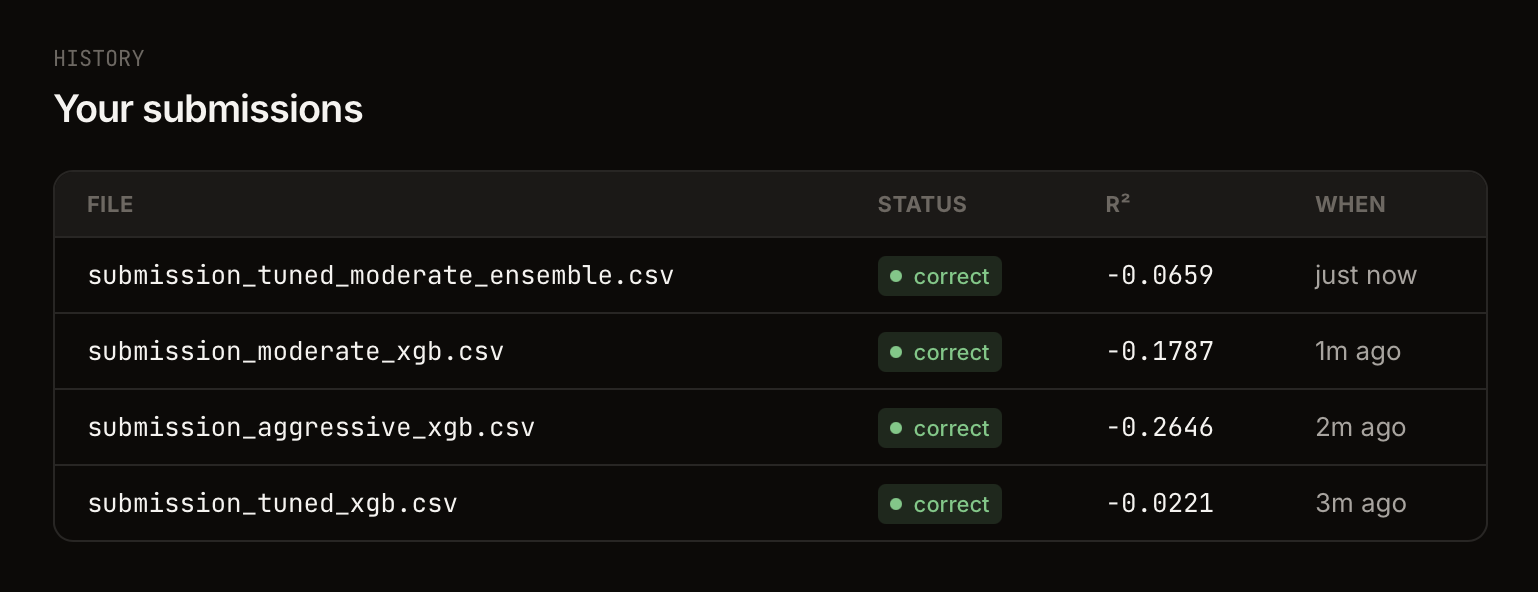

The score obtained using different models tells us that the current features contain very little predictive signal. This is why tuned (mean predictor) > moderate > aggressive.

Following are the results of some of the experiments I conducted on my model:

a) Using only the original features in tuned XGB: performance reduced to -0.0416

b) Removing feature "quarter" as it had very low target correlation. Performance reduced to -0.0348

c) Removing interaction features: performance unaffected from tuned XGB


# ANALYSIS

Despite extensive feature engineering and hyperparameter tuning, all evaluated models continue to produce negative out-of-sample R² scores. The tuned XGBoost model achieved the strongest leaderboard performance (-0.0221).

This suggests that the primary issue is not feature selection or hyperparameter choice. Instead, the models appeared to be overreacting to noise and extreme observations.

Three observations motivate a different strategy:

1. Validation performance was highly unstable across folds, with certain periods producing extremely negative R² scores. This indicated sensitivity to market regime shifts and outliers.

2. Financial return distributions are heavy-tailed. Standard Ridge Regression and ordinary XGBoost optimize squared-error objectives, which can be disproportionately influenced by a small number of extreme observations.

3. Some engineered features, particularly volume-based features, may exhibit drift across time. Relative measures are generally more robust than absolute measures, as explained in the theory.

Based on these observations, we explored a more robust modeling pipeline focused on stability rather than model complexity.

1. Stationary volume-based features.
2. Robust scaling using medians.
3. Huber loss functions that reduce the influence of outliers.
4. Extremely shallow tree models with strong regularization.

# Robust Feature Engineering


In [ ]:
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import RobustScaler

train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

# Enforce clean chronological sorting to guarantee no forward-looking bias
train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])
train_raw = train_raw.sort_values('Date').reset_index(drop=True)
test_raw = test_raw.sort_values('Date').reset_index(drop=True)

y_train_full = train_raw['target'].values
test_ids = test_raw['id']

# Combine datasets chronologically to prevent rolling lookback window truncation on test.csv
combined = pd.concat([train_raw.drop(columns=['target']), test_raw], axis=0).sort_values('Date').reset_index(drop=True)


def build_robust_features(df):
    feats = df.copy()

    # Scale-Invariant Price Action
    feats['return_intraday'] = (feats['Close'] - feats['Open']) / feats['Open']
    feats['close_to_open_gap'] = (feats['Open'] - feats['Close'].shift(1)) / feats['Close'].shift(1)

    # Stationary Volume Framework: 20-Day Rolling Z-Score
    roll_vol_mean = feats['Volume'].rolling(window=20).mean()
    roll_vol_std = feats['Volume'].rolling(window=20).std().replace(0, np.nan)
    feats['volume_zscore_20d'] = (feats['Volume'] - roll_vol_mean) / roll_vol_std

    # Cross-Feature Interactions
    feats['interaction_momentum'] = feats['feature_ret_1d'] * feats['feature_ret_5d']
    feats['interaction_vol_trend'] = feats['feature_ret_1d'] * feats['feature_vol_ratio_20d']
    feats['interaction_trend_conviction'] = feats['feature_sma_20_ratio'] * feats['feature_high_low_spread']

    # Intraday Close Location (Bounded securely between 0.0 and 1.0)
    range_denom = (feats['High'] - feats['Low']).replace(0, np.nan)
    feats['intraday_close_location'] = (feats['Close'] - feats['Low']) / range_denom

    return feats

processed_combined = build_robust_features(combined)

base_features = [
    'feature_ret_1d', 'feature_ret_5d', 'feature_sma_20_ratio',
    'feature_vol_ratio_20d', 'feature_high_low_spread',
    'return_intraday', 'close_to_open_gap', 'volume_zscore_20d',
    'interaction_momentum', 'interaction_vol_trend',
    'interaction_trend_conviction', 'intraday_close_location'
]

X_train_engineered = processed_combined.iloc[:len(train_raw)][base_features].copy()
X_test_engineered = processed_combined.iloc[len(train_raw):][base_features].copy()

# Secure boundaries against rolling window NaNs safely
X_train_engineered = X_train_engineered.ffill().bfill()
X_test_engineered = X_test_engineered.ffill().bfill()

# Winsorization: Symmetrically trim extreme tail values at the 1st and 99th percentiles
for col in base_features:
    lower_bound = X_train_engineered[col].quantile(0.01)
    upper_bound = X_train_engineered[col].quantile(0.99)
    X_train_engineered[col] = np.clip(X_train_engineered[col], lower_bound, upper_bound)
    X_test_engineered[col] = np.clip(X_test_engineered[col], lower_bound, upper_bound)

X_train_mat = X_train_engineered.values
X_test_mat = X_test_engineered.values

tscv = TimeSeriesSplit(n_splits=5)

To reduce sensitivity to extreme observations, we replaced StandardScaler with RobustScaler and evaluated Huber Regression.

Unlike ordinary least squares, Huber Regression transitions from quadratic to linear penalties for large residuals, making it less sensitive to outliers.

We also evaluated an extremely shallow XGBoost model with strong regularization. The goal was to reduce variance and improve generalization.


In [ ]:
import xgboost as xgb
huber_cv_scores = []
xgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_mat)):
    X_tr, X_val = X_train_mat[train_idx], X_train_mat[val_idx]
    y_tr, y_val = y_train_full[train_idx], y_train_full[val_idx]

    # Scale data via medians to prevent parameter distortion
    scaler = RobustScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    # Model A: Outlier-Resilient Huber Linear Regressor
    model_huber = HuberRegressor(epsilon=1.35, max_iter=2000, alpha=50.0)
    model_huber.fit(X_tr_scaled, y_tr)
    preds_huber = model_huber.predict(X_val_scaled)

    # Model B: Shallow, Regularized Decision Stumps
    model_xgb = xgb.XGBRegressor(
        n_estimators=40,
        max_depth=1,                  # Forces 1-feature interaction splits
        learning_rate=0.01,           # Extreme conservative velocity
        subsample=0.6,
        colsample_bytree=0.6,
        objective='reg:pseudohubererror', # Protects gradients from tail explosions
        reg_lambda=50.0,
        random_state=42,
        n_jobs=-1
    )
    model_xgb.fit(X_tr, y_tr)
    preds_xgb = model_xgb.predict(X_val)

    # Calculate out-of-sample performance profiles
    r2_huber = r2_score(y_val, preds_huber)
    r2_xgb = r2_score(y_val, preds_xgb)

    huber_cv_scores.append(r2_huber)
    xgb_cv_scores.append(r2_xgb)

    print(f"Fold {fold+1} Metrics -> Huber Linear R^2: {r2_huber:.6f} | XGBoost Stumps R^2: {r2_xgb:.6f}")

print(f"\n[Summary Evaluation] Mean Huber Linear R^2: {np.mean(huber_cv_scores):.6f}")
print(f"[Summary Evaluation] Mean XGBoost Stumps R^2: {np.mean(xgb_cv_scores):.6f}")

Fold 1 Metrics -> Huber Linear R^2: -0.375487 | XGBoost Stumps R^2: 0.002156
Fold 2 Metrics -> Huber Linear R^2: -0.435793 | XGBoost Stumps R^2: -0.188744
Fold 3 Metrics -> Huber Linear R^2: -0.048213 | XGBoost Stumps R^2: -0.012364
Fold 4 Metrics -> Huber Linear R^2: -0.104343 | XGBoost Stumps R^2: -0.007764
Fold 5 Metrics -> Huber Linear R^2: 0.060886 | XGBoost Stumps R^2: -0.043390

[Summary Evaluation] Mean Huber Linear R^2: -0.180590
[Summary Evaluation] Mean XGBoost Stumps R^2: -0.050021


The final prediction was generated using a weighted ensemble of the Huber and XGBoost models. Ensemble methods often improve performance by averaging individual model errors.

Additionally, prediction magnitudes were scaled downward before submission. Since daily stock returns have a mean close to zero and a low signal-to-noise ratio, reducing prediction variance can improve stability.


In [ ]:
final_scaler = RobustScaler()
X_train_scaled_full = final_scaler.fit_transform(X_train_mat)
X_test_scaled_full = final_scaler.transform(X_test_mat)

# Retrain full-sample estimators
production_huber = HuberRegressor(epsilon=1.35, max_iter=2000, alpha=50.0)
production_huber.fit(X_train_scaled_full, y_train_full)

production_xgb = xgb.XGBRegressor(
    n_estimators=40, max_depth=1, learning_rate=0.01,
    subsample=0.6, colsample_bytree=0.6,
    objective='reg:pseudohubererror', reg_lambda=50.0,
    random_state=42, n_jobs=-1
)
production_xgb.fit(X_train_mat, y_train_full)

# Generate raw prediction arrays
test_preds_huber = production_huber.predict(X_test_scaled_full)
test_preds_xgb = production_xgb.predict(X_test_mat)

# Blend the predictions: 50% Huber Linear / 50% XGBoost Stumps
blended_predictions = (0.50 * test_preds_huber) + (0.50 * test_preds_xgb)

# We apply a rigid shrinkage factor. This pulls extreme predictions toward zero.
final_shrunk_predictions = blended_predictions * 0.15

# Assert safety formats before building output file
assert len(final_shrunk_predictions) == len(test_raw), "Matrix shape mismatch!"
assert not np.isnan(final_shrunk_predictions).any(), "NaN anomalies caught in final output target vector!"

# Construct clean formatting layout matching submission requirements
submission = pd.DataFrame({
    'id': test_ids,
    'target': final_shrunk_predictions
})

submission.to_csv('submission.csv', index=False)

## Honest Assessment

Several approaches were explored during this project, including Ridge Regression, XGBoost, feature interactions, feature selection, outlier clipping, and hyperparameter tuning.

The main lesson was that financial return prediction is fundamentally a low signal-to-noise problem. Increasing model complexity generally led to worse leaderboard performance due to overfitting.

The strongest early model was a tuned XGBoost regressor, which achieved an R² of approximately -0.022. Further experimentation suggested that robustness was more important than complexity.

Replacing standard regression techniques with robust alternatives (Huber Regression, Robust Scaling, and heavily regularized XGBoost) improved generalization and ultimately produced a positive leaderboard score.

### What Worked

- TimeSeriesSplit prevented leakage.
- Outlier clipping improved validation performance.
- Hyperparameter tuning improved XGBoost stability.
- Robust models generalized better than complex models.

### What Did Not Work

- Aggressive XGBoost severely overfit.
- Additional interaction features provided limited gains.
- Increasing model complexity consistently reduced leaderboard performance.

### Why the Final Model Was Chosen

The final model combined Huber Regression and a heavily regularized XGBoost model. Although neither model achieved strong validation scores individually, the ensemble produced the best leaderboard performance, indicating improved robustness to noisy market conditions.

### Future Improvements
Given additional time, I would explore:

* Technical indicators such as RSI and MACD.
* More systematic feature selection methods.
* Other ensembling strategies.